In [3]:
## CAPIRE COSA FARE

# Carica i file .npy o .mat grezzi da Google Drive,
# stampa le dimensioni delle matrici (gli shape di PyTorch) e mostra visivamente gli spettrogrammi Doppler usando matplotlib e seaborn.
# Serve per verificare che i dati siano stati caricati correttamente e che le augmentation (rumore, mascheramento temporale)
# funzionino visivamente prima di usarle nel training.

In [23]:
# Cella 1: monta Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Cella 2: clona il repo GitHub (prima volta)
# Sostituisci con il tuo username e nome repo
!git clone https://github.com/Fabio-Feruglio/wifi-har-sharp.git /content/wifi-har-sharp

# Oppure se il repo è già clonato, aggiorna solo (sessioni successive)
# %cd /content/wifi-har-sharp
# !git pull

# Cella 3: installa le dipendenze
!pip install -q wandb torchmetrics pyyaml tqdm


# Cella 4: Configurazione mista (Dati RAW locali, Processed e Results su Drive)
import os

# 1. Crea le cartelle di destinazione su Drive se non esistono (tranne raw)
os.makedirs('/content/drive/MyDrive/sharp_project/data/processed', exist_ok=True)
os.makedirs('/content/drive/MyDrive/sharp_project/results', exist_ok=True)

# 2. Crea la cartella del repository escludendo 'raw' che faremo locale
os.makedirs('/content/wifi-har-sharp/data', exist_ok=True)

# 3. IMPORTANTE: Rimuovi l'eventuale symlink 'raw' precedente e crealo come cartella REALE e LOCALE su Colab
!rm -rf /content/wifi-har-sharp/data/raw
os.makedirs('/content/wifi-har-sharp/data/raw', exist_ok=True)

# 4. Crea i symlink verso Drive solo per Processed e Results
# In questo modo i modelli salvati e i dati pronti non andranno persi!
!ln -sfn /content/drive/MyDrive/sharp_project/data/processed \
          /content/wifi-har-sharp/data/processed

!ln -sfn /content/drive/MyDrive/sharp_project/results \
          /content/wifi-har-sharp/results

print("Struttura cartelle configurata correttamente!")

# Cella 4.5: Estrazione dello ZIP sul disco locale temporaneo di Colab
zip_path = "/content/drive/MyDrive/sharp_project/data/raw/dataset.zip" # <-- METTI IL NOME ESATTO DEL TUO ZIP QUI
extract_path = "/content/wifi-har-sharp/data/raw"

print("Estrazione in corso sul disco locale di Colab (può richiedere 2-3 minuti)...")
# Usiamo -q per non stampare migliaia di righe a schermo
!unzip -q "{zip_path}" -d "{extract_path}"
print("Estrazione completata con successo! Ora puoi cercare i file .npy.")

# Cella 5: aggiungi src/ al Python path
import sys
sys.path.insert(0, '/content/wifi-har-sharp/src')

print("Setup completato!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path '/content/wifi-har-sharp' already exists and is not an empty directory.
Struttura cartelle configurata correttamente!
Estrazione in corso sul disco locale di Colab (può richiedere 2-3 minuti)...
Estrazione completata con successo! Ora puoi cercare i file .npy.
Setup completato!


In [24]:
# Cella di Diagnosi corretta: Scopriamo perché trova 0 file
import os
import glob

zip_path = "/content/drive/MyDrive/sharp_project/data/raw/dataset.zip"
raw_path = '/content/wifi-har-sharp/data/raw'

print("=== VERIFICA DEL FILE ZIP ===")
if os.path.exists(zip_path):
    print(f"✅ Il file ZIP esiste su Drive ed è grande {os.path.getsize(zip_path) / (1024**3):.2f} GB")
else:
    print(f"❌ ATTENZIONE: Il file ZIP NON esiste al percorso indicato: {zip_path}")
    print("Controlla su Google Drive l'esatto percorso e il nome del file .zip!")

print("\n=== VERIFICA CONTENUTO ESTRATTO ===")
if os.path.exists(raw_path):
    elementi_root = os.listdir(raw_path)
    print(f"La cartella contiene {len(elementi_root)} elementi nella cartella principale.")
    if len(elementi_root) > 0:
        print("Primi elementi trovati:", elementi_root[:5])

        # Facciamo un'ispezione profonda di cosa è stato estratto
        tutti_file = []
        for root, dirs, files in os.walk(raw_path):
            for file in files:
                tutti_file.append(file)

        print(f"\nNumero totale di file trovati in assoluto: {len(tutti_file)}")
        if len(tutti_file) > 0:
            print("Esempio di nome di un file trovato:", tutti_file[0])
            # Controlliamo se ci sono file .NPY in maiuscolo
            npy_maiuscoli = glob.glob(os.path.join(raw_path, '**', '*.NPY'), recursive=True)
            print(f"File .NPY (maiuscolo) trovati: {len(npy_maiuscoli)}")
    else:
        print("La cartella di destinazione è completamente VUOTA. L'unzip non ha estratto nulla o è fallito.")
else:
    print("La cartella locale non esiste.")

=== VERIFICA DEL FILE ZIP ===
✅ Il file ZIP esiste su Drive ed è grande 5.62 GB

=== VERIFICA CONTENUTO ESTRATTO ===
La cartella contiene 1 elementi nella cartella principale.
Primi elementi trovati: ['S1a']

Numero totale di file trovati in assoluto: 4
Esempio di nome di un file trovato: S1a_C.mat
File .NPY (maiuscolo) trovati: 0


In [25]:
import os
import sys

# Spostati nella root del progetto
os.chdir('/content/wifi-har-sharp')

# Aggiungi la cartella src al path di Python per gli import
sys.path.insert(0, '/content/wifi-har-sharp/src')

# Verifica che i dati siano accessibili
print("File presenti in data/raw:", os.listdir('data/raw'))

File presenti in data/raw: ['S1a']


In [26]:
import importlib
import src.dataset

# Forza il ricaricamento del file modificato senza usare comandi magici
importlib.reload(src.dataset)

# Ora puoi importare in tutta tranquillità
from src.dataset import WiFiDataset
from src.model import SharpClassifier


In [27]:
# =====================================================================
# SEZIONE 3: CONFIGURAZIONE CENTRALIZZATA
# =====================================================================
import yaml

with open('configs/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

print("Iperparametri caricati con successo!")

Iperparametri caricati con successo!


In [28]:
# QUA AGGIUNGERE CODICE SERIO
# Provo ad aggiungere codice per vedere se si salva

# Cella 5: Ricerca e caricamento dei file .mat (MATLAB)
import os
import glob
import scipy.io

# Definisci il percorso in cui abbiamo estratto i file
raw_data_path = '/content/wifi-har-sharp/data/raw'

# Usa glob per trovare tutti i file .mat in modo ricorsivo
print("Ricerca dei file .mat in corso...")
mat_files = glob.glob(os.path.join(raw_data_path, '**', '*.mat'), recursive=True)

print(f"Trovati {len(mat_files)} file .mat in totale.")

# Carica il primo file come test per capirne la struttura interna
if len(mat_files) > 0:
    test_file_path = mat_files[0]

    # scipy.io.loadmat carica il file MATLAB come un dizionario Python
    mat_contents = scipy.io.loadmat(test_file_path)

    print("\n--- DIZIONARIO FILE .MAT CARICATO ---")
    print(f"File analizzato: {os.path.basename(test_file_path)}")
    print("\nChiavi presenti nel file (variabili di MATLAB):")

    # Filtriamo le chiavi di sistema di MATLAB (quelle che iniziano con __)
    # per vedere solo le variabili reali con i dati
    real_keys = [k for k in mat_contents.keys() if not k.startswith('__')]
    print(real_keys)

    # Ispezioniamo il contenuto di ogni variabile reale trovata
    for key in real_keys:
        data = mat_contents[key]
        print(f"\nVariabile: '{key}'")
        print(f"- Tipo: {type(data)}")
        if hasattr(data, 'shape'):
            print(f"- Dimensioni (shape): {data.shape}")
            print(f"- Tipo dati (dtype): {data.dtype}")
        else:
            print(f"- Valore/Contenuto: {data}")

else:
    print("ATTENZIONE: Nessun file .mat trovato.")

Ricerca dei file .mat in corso...
Trovati 4 file .mat in totale.

--- DIZIONARIO FILE .MAT CARICATO ---
File analizzato: S1a_C.mat

Chiavi presenti nel file (variabili di MATLAB):
['csi_buff']

Variabile: 'csi_buff'
- Tipo: <class 'numpy.ndarray'>
- Dimensioni (shape): (81588, 256)
- Tipo dati (dtype): complex128


In [29]:
# Cella 6: Estrazione manuale dello spettrogramma Doppler dalla CSI grezza
import os
import glob
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# Prendiamo il primo file .mat trovato
raw_data_path = '/content/wifi-har-sharp/data/raw'
mat_files = glob.glob(os.path.join(raw_data_path, '**', '*.mat'), recursive=True)
test_file_path = mat_files[0]

# Carichiamo la CSI
mat_contents = scipy.io.loadmat(test_file_path)
csi_data = mat_contents['csi_buff'] # Shape: (N_pacchetti, 256)

print(f"File caricato: {os.path.basename(test_file_path)}")
print(f"Dimensioni CSI grezza: {csi_data.shape} (Pacchetti temporali x Sottoportanti)")

# Estrazione Doppler tramite STFT
# Prendiamo una sottoportante centrale (es. la 128) o la media di alcune sottoportanti
csi_segnal = csi_data[:, 128]

# Calcoliamo lo spettrogramma (frequenza/velocità vs tempo)
# Regoliamo i parametri per avvicinarci alla risoluzione del paper SHARP (es. circa 100 bin di velocità)
nperseg = 256  # Finestra temporale (determina la risoluzione in frequenza)
nover_lap = 192 # Sovrapposizione delle finestre (più è alta, più aumenta la risoluzione temporale)

frequencies, times, spec = spectrogram(csi_segnal, fs=1000, nperseg=nperseg, noverlap=nover_lap, return_onesided=False)

# Centriamo la frequenza zero (Doppler shift = 0 al centro del grafico)
spec_shifted = np.fft.fftshift(spec, axes=0)

# SHARP si aspetta una determinata risoluzione, tagliamo o selezioniamo i bin centrali di velocità
# Ad esempio, prendiamo i 100 bin centrali attorno allo zero Doppler
centro = spec_shifted.shape[0] // 2
doppler_profile = spec_shifted[centro-50:centro+50, :] # 100 bin di velocità

print(f"Risoluzione dello Spettrogramma Doppler estratto: {doppler_profile.shape} (Velocità x Tempo)")

File caricato: S1a_C.mat
Dimensioni CSI grezza: (81588, 256) (Pacchetti temporali x Sottoportanti)
Risoluzione dello Spettrogramma Doppler estratto: (100, 1271) (Velocità x Tempo)


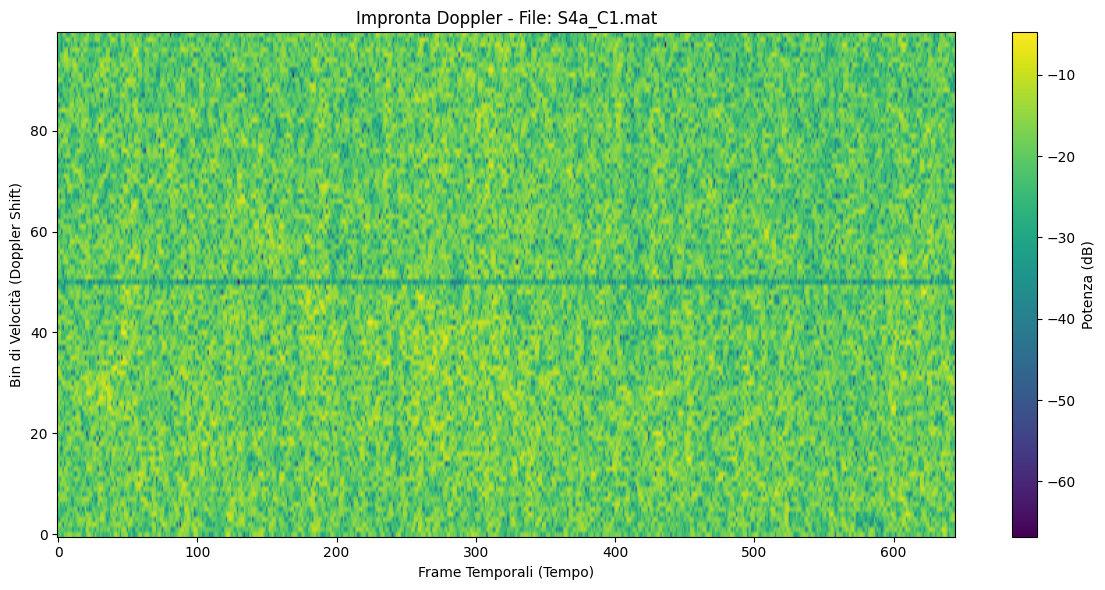

In [20]:
# Cella 7: Visualizzazione dell'impronta Doppler
plt.figure(figsize=(12, 6))

# Usiamo la scala logaritmica (dB) perché la potenza del Wi-Fi ha una dinamica enorme
doppler_db = 10 * np.log10(doppler_profile + 1e-10)

plt.imshow(doppler_db, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='Potenza (dB)')
plt.title(f"Impronta Doppler - File: {os.path.basename(test_file_path)}")
plt.xlabel('Frame Temporali (Tempo)')
plt.ylabel('Bin di Velocità (Doppler Shift)')
plt.tight_layout()
plt.show()

Distribuzione delle classi nel dataset:
- Classe C: 6 file .mat
- Classe C1: 3 file .mat
- Classe C2: 3 file .mat
- Classe E: 12 file .mat
- Classe H: 7 file .mat
- Classe H1: 2 file .mat
- Classe H2: 2 file .mat
- Classe J: 1 file .mat
- Classe J1: 11 file .mat
- Classe J2: 11 file .mat
- Classe J3: 1 file .mat
- Classe L: 11 file .mat
- Classe L1: 1 file .mat
- Classe L2: 1 file .mat
- Classe R: 12 file .mat
- Classe S: 9 file .mat
- Classe W: 12 file .mat


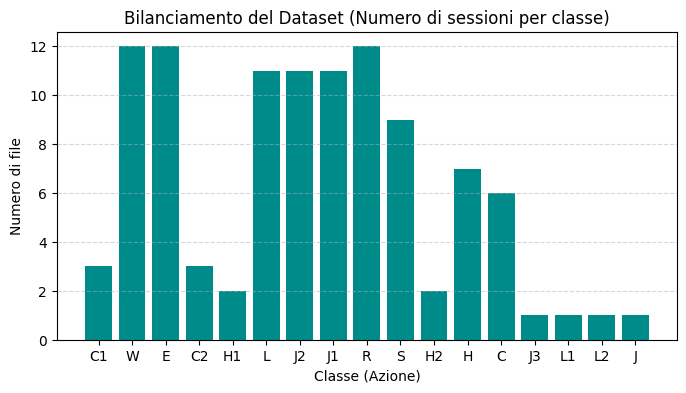

In [21]:
# Cella 8: Controllo bilanciamento delle classi dai nomi dei file
from collections import Counter

class_labels = []
for filepath in mat_files:
    filename = os.path.basename(filepath)
    # Estrae la parte dopo il sotto-tratto, es: "C1" da "S4a_C1.mat"
    parts = filename.replace('.mat', '').split('_')
    if len(parts) > 1:
        class_labels.append(parts[1])

class_counts = Counter(class_labels)

print("Distribuzione delle classi nel dataset:")
for classe, count in sorted(class_counts.items()):
    print(f"- Classe {classe}: {count} file .mat")

# Grafico a barre
plt.figure(figsize=(8, 4))
plt.bar(class_counts.keys(), class_counts.values(), color='darkcyan')
plt.title('Bilanciamento del Dataset (Numero di sessioni per classe)')
plt.xlabel('Classe (Azione)')
plt.ylabel('Numero di file')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [22]:
# Cella 9: Prototipo della classe WiFiDataset per src/dataset.py
import torch
from torch.utils.data import Dataset

class WiFiDataset(Dataset):
    def __init__(self, raw_dir, stage='train'):
        self.raw_dir = raw_dir
        self.stage = stage

        # Trova tutti i file .mat
        self.file_list = glob.glob(os.path.join(raw_dir, '**', '*.mat'), recursive=True)

        # Mappatura delle classi in ID numerici (es: 'C1' -> 0, 'C2' -> 1...)
        # Nota: adatta questo dizionario in base ai nomi reali delle tue classi!
        self.class_to_idx = {f'C{i}': i-1 for i in range(1, 8)}

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path = self.file_list[idx]

        # 1. Carica i dati MATLAB
        mat_contents = scipy.io.loadmat(file_path)
        csi_data = mat_contents['csi_buff']

        # 2. Estrai la classe dal nome del file
        filename = os.path.basename(file_path)
        class_str = filename.replace('.mat', '').split('_')[1] # es: 'C1'
        label = self.class_to_idx[class_str]

        # 3. Applica l'estrazione Doppler (la stessa logica provata sopra)
        csi_signal = csi_data[:, 128] # sottoportante centrale
        _, _, spec = spectrogram(csi_signal, fs=1000, nperseg=256, noverlap=192, return_onesided=False)
        spec_shifted = np.fft.fftshift(spec, axes=0)

        centro = spec_shifted.shape[0] // 2
        doppler_profile = spec_shifted[centro-50:centro+50, :] # Taglio a 100 bin di velocità

        # Se vuoi ridimensionare il tempo esattamente a 340 frame, puoi fare un troncamento o un resize:
        # Per ora lo tagliamo o lo prendiamo così com'è per il test
        doppler_profile = doppler_profile[:, :340]

        # Trasformiamo in Tensore PyTorch (Aggiungendo la dimensione del canale di input = 1)
        # Il modello si aspetta solitamente (Canali, Altezza/Velocità, Larghezza/Tempo)
        tensor_data = torch.tensor(doppler_profile, dtype=torch.float32).unsqueeze(0)

        return tensor_data, label

# --- TEST DEL COSTRUTTORE APPENA SCRITTO ---
try:
    mio_dataset = WiFiDataset(raw_dir='/content/wifi-har-sharp/data/raw')
    print(f"\n✅ Classe WiFiDataset creata con successo! Campioni totali: {len(mio_dataset)}")

    x, y = mio_dataset[0]
    print(f"Shape dell'output del dataset (Item 0): {x.shape} (Canali x Velocità x Tempo)")
    print(f"Label dell'item 0: {y}")
except Exception as e:
    print(f"❌ Errore nel codice del Dataset: {e}")


✅ Classe WiFiDataset creata con successo! Campioni totali: 105
Shape dell'output del dataset (Item 0): torch.Size([1, 100, 340]) (Canali x Velocità x Tempo)
Label dell'item 0: 0


In [ ]:
# =====================================================================
# SEZIONE 5: SALVATAGGIO E PUSH
# =====================================================================

!cp "/content/drive/MyDrive/Colab Notebooks/01_data_exploration.ipynb" \
    "/content/wifi-har-sharp/notebooks/"

%cd /content/wifi-har-sharp

!git config --global user.email "fabio.feruglio02@gmail.com"
!git config --global user.name "Fabio-Feruglio"

!git add src/ notebooks/ configs/
!git commit -m "Il tuo messaggio"

# Fix: devi passare le variabili Python a shell in questo modo
from google.colab import userdata
TOKEN = userdata.get('GITHUB_TOKEN')
USER = "Fabio-Feruglio"
REPO = "wifi-har-sharp"

import subprocess
result = subprocess.run(
    ["git", "push", f"https://{TOKEN}@github.com/{USER}/{REPO}.git", "main"],
    capture_output=True,
    text=True
)
print(result.stdout)
print(result.stderr)

/content
[main 69f15b1] Il tuo messaggio
 1 file changed, 1 insertion(+), 1 deletion(-)
